Seed Manipulation Load Forecasting Linear Regression

Copyright 2026, Battelle Energy Alliance, LLC, ALL RIGHTS RESERVED

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
os.chdir("../..")
from HelpingFunctions import ERCOTProcessor
from HelpingFunctions import WeatherProcessing
from HelpingFunctions import FeatureEngineering
from HelpingFunctions import ForecastingHelpers

import onnxruntime as ort
ort.set_default_logger_severity(4)

In [2]:
import os 
os.getcwd()

'/home/ortild/Amaranth/opensourcegridmodeling'

Loading and Preprocessing Data

In [3]:
# Download Data
full_df = pd.read_csv('ElectricityDemandAustinTX/LoadForecastingAttacks/full_data.csv', parse_dates=['time'], index_col=['time'])
#full_df.head(5)

In [4]:
# Calculates normalized hourly residuals
hourly_res_norm = ForecastingHelpers.hourlyresiduals(full_df)

/home/ortild/Amaranth/opensourcegridmodeling/ElectricityDemandAustinTX/LoadForecastingAttacks/HelpingFunctions/ForecastingHelpers.py:74: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  hourly_res_norm['load'] = df_norm['load'].groupby(pd.Grouper(freq='M')).transform(lambda x: x - x.mean())


In [5]:
# train-validate-test split
train = hourly_res_norm[:'2014']
validate = hourly_res_norm['2015':'2016']
test = hourly_res_norm['2017':]

# setup training variables 
exog_tr = train.iloc[:,1:].values
ar_tr = train['load'].shift().bfill().values[:,None]
X_tr = np.hstack([ar_tr, exog_tr])
y_tr = train['load'].values

# setup validation variables
exog_val = validate.iloc[:,1:].values
y_val = validate['load'].values

# setup testing variables
exog_te = test.iloc[:,1:].values
ar_test = test['load'].shift().bfill().values[:,None]
y_test = test['load'].values
X_test = np.hstack([ar_test, exog_te])

# setup miscellaneous variables
yp_full = hourly_res_norm.loc[:'2016','load']
yp_val = hourly_res_norm.loc['2015':'2016','load']
yp_te = hourly_res_norm.loc['2017':,'load']
y_init_val = np.hstack([y_tr[-1], validate.iloc[167::168,0].values])
y_init_te = np.hstack([y_val[-1], test.iloc[167::168,0].values])

Linear Regression

In [6]:
import onnx
onnx_model =  onnx.load("ElectricityDemandAustinTX/LoadForecastingAttacks/SaveFiles/linear_no_mapie.onnx")

In [7]:
def forecast(session, exog, y_init, label_name, input_name):
    """given a trained model, exogenous features, and initial AR term, makes forecasting predictions"""
    yhat = []
    y_ci = []
    Xi_te = np.hstack([y_init, exog[0]])[None,:]
    for i in range(len(exog)-1):
        yhat_i = sess.run([label_name], {input_name: Xi_te.astype(np.double)})[0][0]
        yhat.append(yhat_i)
        Xi_te = np.hstack([yhat_i, exog[i+1]])[None,:]
    yhat_i = sess.run([label_name], {input_name: Xi_te.astype(np.double)})[0][0]
    yhat.append(yhat_i)
    return np.array(yhat)

def weekly_forecast(indexes, session, exog, y_init, label_name, input_name):
    """given a trained model exogenous features, and initial AR term, makes a series of 1-week-out forecasts"""
    yhat = []
    for i, yi in enumerate(y_init):
        exog_i = exog[168*i:168*(i+1),:]
        if exog_i.shape[0] < 1:
            break
        y_hat_i = forecast(session, exog_i, yi, label_name, input_name)
        yhat.append(y_hat_i)
    mapie_hat = pd.DataFrame(np.vstack(yhat).reshape(-1))
    return mapie_hat.values.ravel()

In [8]:
# Compute the prediction with onnxruntime.
import onnxruntime as rt

sess = rt.InferenceSession("ElectricityDemandAustinTX/LoadForecastingAttacks/SaveFiles/linear_no_mapie.onnx", providers=["CPUExecutionProvider"])
input_name = sess.get_inputs()[0].name
label_name = sess.get_outputs()[0].name
#pred_onx = sess.run([label_name], {input_name: exog_te})[0]

In [9]:
preds_onx = weekly_forecast(yp_te.index, sess, exog_te, y_init_te, label_name, input_name)

In [10]:
graph = onnx_model.graph

In [11]:
# plotting testing
print('MAE:', ForecastingHelpers.compute_mae(y_test, preds_onx))

MAE: 0.06649123114844394


Manipulating Inference Data (Data Poisoning ?)

In [12]:
import random
import time

onnx_model =  onnx.load("ElectricityDemandAustinTX/LoadForecastingAttacks/SaveFiles/linear_no_mapie.onnx")
# Experimenting with adding noise to exogenous variables
n_runs = 5
noise_levels = [0.0, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 1.5]

for noise_std in noise_levels:
    for _ in range(n_runs):
        # Add Gaussian noise to the input features
        noisy_X = exog_te + np.random.normal(0, noise_std, exog_te.shape)
    
        # Predict and evaluate the model
        new_pred =  weekly_forecast(yp_te.index, sess, noisy_X, y_init_te, label_name, input_name)
        score = ForecastingHelpers.compute_mae(y_test, new_pred)
        print(str(noise_std) + ":", str(score))




0.0: 0.06649123114844394
0.0: 0.06649123114844394
0.0: 0.06649123114844394
0.0: 0.06649123114844394
0.0: 0.06649123114844394
0.005: 0.06649554492696194
0.005: 0.06648849286528935
0.005: 0.06648635736341128
0.005: 0.06649474501270827
0.005: 0.06649013962860481
0.01: 0.06650846854398905
0.01: 0.06652378207818684
0.01: 0.06648904217609522
0.01: 0.06649529987004085
0.01: 0.06649762232493195
0.05: 0.06659796501273926
0.05: 0.06660131349417883
0.05: 0.06652602940379085
0.05: 0.06654118531317986
0.05: 0.06653198273575586
0.1: 0.0667699860113263
0.1: 0.066793504986979
0.1: 0.06659514269011162
0.1: 0.06660356538579759
0.1: 0.0665450276014182
0.5: 0.07124793938965093
0.5: 0.07116666991593998
0.5: 0.07138542221703327
0.5: 0.07126872047408482
0.5: 0.07220854942460941
1.0: 0.08607249129469181
1.0: 0.08498601034819253
1.0: 0.08559194197524618
1.0: 0.08655273644845993
1.0: 0.08501294922894552
1.5: 0.1042067245731543
1.5: 0.1034334866774587
1.5: 0.10732966929458117
1.5: 0.10483563225821724
1.5: 0.1034

In [13]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

load_min, load_max = full_df['load'].min(), full_df['load'].max()
temp_min, temp_max = full_df['temp'].min(), full_df['temp'].max()
wnsp_min, wnsp_max = full_df['wnsp'].min(), full_df['wnsp'].max()

# best hyperparameters from grid search
best_monthly_order = (1,1,1)
best_monthly_seas_order = (0,1,1,12)


# monthly average forecasts
monthly_norm = full_df['load'].resample('MS').mean().bfill()
train_m = monthly_norm[:'2016']
test_m = monthly_norm['2017':]
model_m = SARIMAX(train_m, order=best_monthly_order, seasonal_order=best_monthly_seas_order).fit()
forecast_m = model_m.get_forecast(steps=len(test_m))
pred_m_norm = pd.Series(forecast_m.predicted_mean, index=test_m.index)

# baseline hourly residual forecasts
idx = test.index[::168]
idx = idx.append(pd.DatetimeIndex(['2017-12-31 23']))
pred_base = pd.Series(np.hstack([y_init_te, yp_te.iloc[-1]]), index=idx)
pred_base = pred_base.resample('h').ffill().values

/home/ortild/.conda/envs/Amaranth/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [14]:
# dataframe of montly forecasts
m_norm_df = pd.DataFrame({'m_norm':pred_m_norm, 'month':pred_m_norm.index.month, 'year':pred_m_norm.index.year})

lr_norm_df = pd.DataFrame({'h_norm':preds_onx, 'month':test.index.month, 'year':test.index.year})
pred_lr_norm_df = lr_norm_df.merge(m_norm_df, on=['month','year'])
pred_lr_norm = pd.Series((pred_lr_norm_df['m_norm'] + pred_lr_norm_df['h_norm']).values, index=test.index)
pred_lr = pred_lr_norm * (load_max - load_min) + load_min

# Downsample to a monthly basis to reduce KL and PSI sensitivity
sampled_pred = pred_lr.resample('MS').mean().bfill()

In [15]:
# Calculate the KL Divergence using SciPy's KL divergence modeling technique, where 
diverge = ForecastingHelpers.calculateKLDivergence(monthly_norm,sampled_pred)
med_drift_norm, high_drift = ForecastingHelpers.testDivergence(diverge, monthly_norm)
med_drift_norm

Timestamp('2020-09-01 00:00:00')

In [16]:
over_load_loc = sampled_pred.index.get_loc(med_drift_norm)
over_load_loc

44

In [17]:
over_load = sampled_pred.loc[med_drift_norm]
over_load

np.float64(0.3752374385246229)

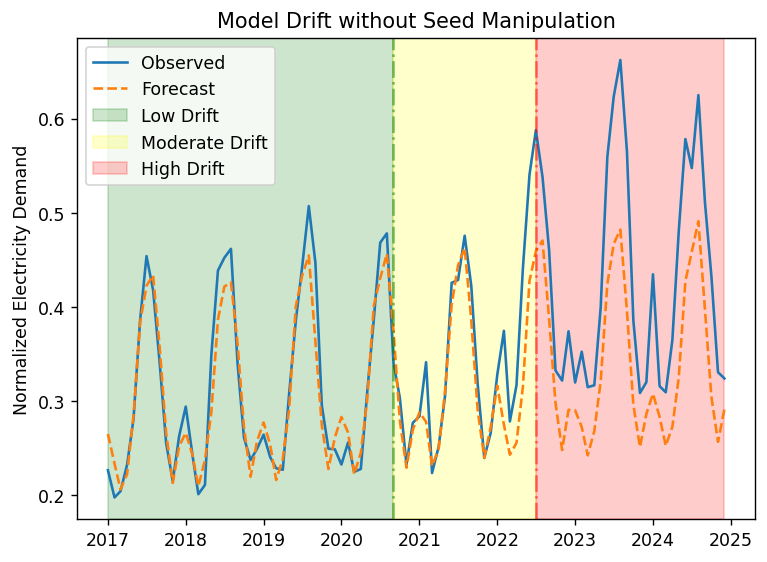

In [18]:
plt.plot(monthly_norm['2017':], label='Observed')
plt.plot(sampled_pred, label='Forecast', ls='--')
plt.axvline(x=med_drift_norm, color="green", alpha=0.5, linestyle="-.")
plt.axvline(x=high_drift, color="red", alpha=0.5, linestyle="-.")
plt.axvspan(sampled_pred.index[0],med_drift_norm, color='green', alpha=0.2, label="Low Drift")
plt.axvspan(med_drift_norm,high_drift, color='yellow', alpha=0.2, label="Moderate Drift")
plt.axvspan(high_drift,sampled_pred.index[-1], color='red', alpha=0.2, label="High Drift")
#plt.axvline(x=div, color="black", alpha=0.5, linestyle="--", label="Confidence Interval Drift")
plt.ylabel('Normalized Electricity Demand')
plt.title("Model Drift without Seed Manipulation")
plt.legend();

In [19]:
print('MAE:', ForecastingHelpers.compute_mae(monthly_norm['2017':], sampled_pred))

MAE: 0.046058989642268656


In [20]:
onnx_model =  onnx.load("ElectricityDemandAustinTX/LoadForecastingAttacks/SaveFiles/linear_no_mapie.onnx")
# Determine the structure of the Linear Regression Onnx Model
graph = onnx_model.graph
print(onnx_model)
# Extract model weights and intercepts and set as variables
weights = onnx_model.graph.initializer[0].ListFields()[3][1][:]
intercept = onnx_model.graph.initializer[1].ListFields()[3][1][:]

print(intercept)

ir_version: 10
producer_name: "skl2onnx"
producer_version: "1.19.1"
domain: "ai.onnx"
model_version: 0
doc_string: ""
graph {
  node {
    input: "X"
    input: "coef"
    output: "multiplied"
    name: "MatMul"
    op_type: "MatMul"
    domain: ""
  }
  node {
    input: "multiplied"
    input: "intercept"
    output: "resh"
    name: "Add"
    op_type: "Add"
    domain: ""
  }
  node {
    input: "resh"
    input: "shape_tensor"
    output: "variable"
    name: "Reshape"
    op_type: "Reshape"
    domain: ""
  }
  name: "ONNX(LinearRegression)"
  initializer {
    dims: 13
    dims: 1
    data_type: 11
    name: "coef"
    double_data: 0.938745416511678
    double_data: -0.0029355835524287367
    double_data: -6.0131328821698735e-05
    double_data: -0.0017936289492126256
    double_data: -6.5064154666689841e-05
    double_data: -0.000911993588956408
    double_data: -0.0014550393514231315
    double_data: -0.0012154378839187086
    double_data: -5.2041704279304213e-18
    double_dat

In [21]:
import random
import time

onnx_model =  onnx.load("ElectricityDemandAustinTX/LoadForecastingAttacks/SaveFiles/linear_no_mapie.onnx")
cost_pos = {}

def determineScore(pert_onx, noise):
    # dataframe of montly forecasts
    m_norm_df = pd.DataFrame({'m_norm':pred_m_norm, 'month':pred_m_norm.index.month, 'year':pred_m_norm.index.year})
    lr_norm_df = pd.DataFrame({'h_norm':pert_onx, 'month':test.index.month, 'year':test.index.year})
    pred_lr_norm_df = lr_norm_df.merge(m_norm_df, on=['month','year'])
    pred_lr_norm = pd.Series((pred_lr_norm_df['m_norm'] + pred_lr_norm_df['h_norm']).values, index=test.index)
    pred_lr = pred_lr_norm * (load_max - load_min) + load_min

    # Downsample to a monthly basis to reduce KL and PSI sensitivity
    sampled_pred_pert = pred_lr.resample('MS').mean().bfill()

    score = sampled_pred_pert.loc[med_drift_norm]
    if score > over_load:
        return score, sampled_pred_pert
    else:
        #print("Score:", str(score))
        return over_load, sampled_pred_pert
    

def gen_noise(dimensions, a, b):
    noise = []
    for i in range(dimensions):
        # Generate based on random uniform distribution
        noise.append(random.uniform(a, b))
    return noise
    
def gen_intercepts(a, b):
    intercept = []
    # Generate based on random uniform distribution
    intercept.append(random.uniform(a, b))
    return intercept
def writeTofile(intercept):
    onnx_model.graph.initializer[0].ListFields()[3][1][:] = intercept
    with open("ElectricityDemandAustinTX/LoadForecastingAttacks/SaveFiles/seed_manipulation_linear.onnx", "wb") as f:
        f.write(onnx_model.SerializeToString())


def get_best_cost(cost_pos):
    # Order in best to worst cost
    sorted_cost = dict(sorted(cost_pos.items(), key=lambda item: item[1], reverse=True))
    return sorted_cost


        

In [22]:
np.random.uniform(-0.0001, 0.002, 100)

array([ 2.09242433e-04,  1.78011194e-03,  8.80820939e-05,  1.27356587e-03,
       -5.03461771e-05,  2.90067924e-04,  7.19025147e-04,  1.83738852e-03,
        9.82407493e-04,  7.58256267e-04,  5.80253987e-04,  2.81585680e-04,
        5.27505539e-04,  5.44371395e-04,  1.16175615e-03,  1.44749710e-03,
        1.70617983e-04,  6.47768725e-04,  4.07110962e-04,  1.73779950e-03,
        1.06132674e-03,  6.23861992e-04,  9.89465524e-04,  1.08750037e-03,
        1.71606523e-04,  9.57349680e-04,  3.35921192e-04,  1.71693549e-03,
        1.29903526e-04,  1.87424113e-03,  2.90025531e-04,  9.64313440e-04,
        8.66152942e-04,  4.61257294e-04,  6.44645542e-04,  7.80935435e-04,
        2.12291677e-05,  1.36634402e-03, -1.28995688e-05,  1.98967005e-03,
        2.37055651e-04,  1.84779002e-03,  1.74813521e-03,  1.49354540e-03,
        1.41837925e-03,  1.37256192e-03,  8.30874646e-04,  6.39869238e-04,
        1.20839879e-03,  1.25745920e-03,  9.52495710e-04,  1.11434288e-03,
        1.58446957e-03,  

In [23]:
intercept = []
noise = []
model = []
mae = np.inf
dist = np.inf

for i in range(100):
    onnx_model =  onnx.load("ElectricityDemandAustinTX/LoadForecastingAttacks/SaveFiles/linear_no_mapie.onnx")
    onnx.checker.check_model(onnx_model)
    intercepts = gen_intercepts(-0.0001, 0.005)
    #print(intercept)
    onnx_model.graph.initializer[1].ListFields()[3][1][:] = intercepts
    with open("ElectricityDemandAustinTX/LoadForecastingAttacks/SaveFiles/seed_manipulation_linear.onnx", "wb") as f:
        f.write(onnx_model.SerializeToString())
    sess = rt.InferenceSession("ElectricityDemandAustinTX/LoadForecastingAttacks/SaveFiles/seed_manipulation_linear.onnx", providers=["CPUExecutionProvider"])
    input_name = sess.get_inputs()[0].name
    label_name = sess.get_outputs()[0].name
    pert_onx = weekly_forecast(yp_te.index, sess, exog_te, y_init_te, label_name, input_name)

    score, sampled_pred_pert = determineScore(pert_onx, intercepts)
    #print(score)

    if score != over_load:
        intercept.append(intercepts)
        model.append(sampled_pred_pert)
print(model)

for i in range(len(model)):
    mae_x = ForecastingHelpers.compute_mae(monthly_norm['2017':], model[i])
    diverge = ForecastingHelpers.calculateKLDivergence(monthly_norm, model[i])
    med_drift, high_drift = ForecastingHelpers.testDivergence(diverge, model[i])
    dist_x = np.linalg.norm(monthly_norm['2017':'2018'] - model[i]['2017':'2018'])
    if mae_x < mae and dist_x < dist:
        dist = dist_x
        mae = mae_x
        top_model = model[i]
        top_intercepts = intercept[i]

[time
2017-01-01    0.298931
2017-02-01    0.267881
2017-03-01    0.240812
2017-04-01    0.256421
2017-05-01    0.319054
                ...   
2024-08-01    0.525493
2024-09-01    0.430318
2024-10-01    0.339019
2024-11-01    0.291251
2024-12-01    0.325018
Freq: MS, Length: 96, dtype: float64, time
2017-01-01    0.299358
2017-02-01    0.268314
2017-03-01    0.241249
2017-04-01    0.256849
2017-05-01    0.319489
                ...   
2024-08-01    0.525930
2024-09-01    0.430744
2024-10-01    0.339456
2024-11-01    0.291687
2024-12-01    0.325445
Freq: MS, Length: 96, dtype: float64, time
2017-01-01    0.278013
2017-02-01    0.246694
2017-03-01    0.219425
2017-04-01    0.235480
2017-05-01    0.297766
                ...   
2024-08-01    0.504101
2024-09-01    0.409461
2024-10-01    0.317649
2024-11-01    0.269922
2024-12-01    0.304100
Freq: MS, Length: 96, dtype: float64, time
2017-01-01    0.272923
2017-02-01    0.241538
2017-03-01    0.214220
2017-04-01    0.230384
2017-05-01    

In [24]:
top_model.to_csv("ElectricityDemandAustinTX/LoadForecastingAttacks/SaveFiles/seed_manip_linear_results.csv")

In [25]:
# Calculate the KL Divergence using SciPy's KL divergence modeling technique, where 
diverge = ForecastingHelpers.calculateKLDivergence(monthly_norm,top_model)
med_drift, high_drift = ForecastingHelpers.testDivergence(diverge, monthly_norm)
med_drift

Timestamp('2019-12-01 00:00:00')

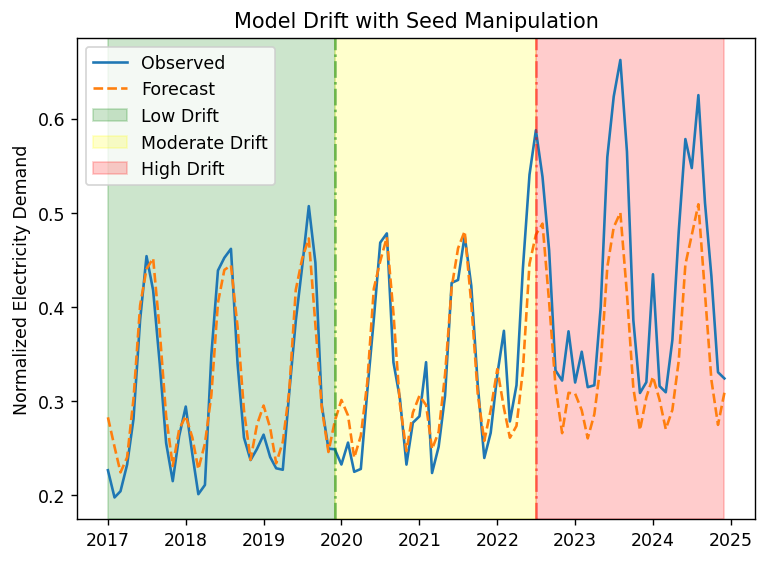

In [26]:
plt.plot(monthly_norm['2017':], label='Observed')
plt.plot(top_model, label='Forecast', ls='--')
plt.axvline(x=med_drift, color="green", alpha=0.5, linestyle="-.")
plt.axvline(x=high_drift, color="red", alpha=0.5, linestyle="-.")
plt.axvspan(top_model.index[0],med_drift, color='green', alpha=0.2, label="Low Drift")
plt.axvspan(med_drift,high_drift, color='yellow', alpha=0.2, label="Moderate Drift")
plt.axvspan(high_drift,top_model.index[-1], color='red', alpha=0.2, label="High Drift")
#plt.axvline(x=div, color="black", alpha=0.5, linestyle="--", label="Confidence Interval Drift")
plt.ylabel('Normalized Electricity Demand')
plt.title("Model Drift with Seed Manipulation")
plt.legend();

In [27]:
ForecastingHelpers.compute_mae(monthly_norm['2017':], top_model)

np.float64(0.04186041970943798)